In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly_express as px 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
data = yf.download("AAPL", start='2020-01-01', end='2026-04-17')

[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [5]:
data.columns = data.columns.droplevel(1)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1580 entries, 2020-01-02 to 2026-04-16
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1580 non-null   float64
 1   High    1580 non-null   float64
 2   Low     1580 non-null   float64
 3   Open    1580 non-null   float64
 4   Volume  1580 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.1 KB


In [7]:
# Calculating Price Change
data['Price_Change'] = data['Close'].diff()
data['pct_change'] = data['Close'].pct_change() * 100
data.fillna(0,inplace=True)
data.head(5)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change
Date,,,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400,0.000000,0.000000
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800,-0.703850,-0.972162
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.571289,0.796814
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,-0.339890,-0.470319
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,1.157051,1.608623


In [8]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Change', 'pct_change'], dtype='object', name='Price')

In [9]:
# Seprating Gain and loss
data["Gain"] = data["Price_Change"].clip(lower=0)
data["Loss"] = -data["Price_Change"].clip(upper=0)

In [10]:
# Rolling Average
data['Avg_Gain'] = data['Gain'].rolling(5).mean()
data['Avg_Loss'] = data['Loss'].rolling(5).mean()

In [11]:
# Relative Strength
data['RS'] = data['Avg_Gain'] / data['Avg_Loss']

In [12]:
# RSI 
data['RSI'] = 100 - (100/(1 + data['RS']))

In [13]:
# Signal
data["Signal"] = "HOLD"
data.loc[(data["RSI"] < 30) & (data["RSI"].shift(1) >= 30), "Signal"] = "BUY"
data.loc[(data["RSI"] > 70) & (data["RSI"].shift(1) <= 70), "Signal"] = "SELL"

In [14]:
data.dropna(inplace=True)

In [15]:
data.head(21)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,Avg_Loss,RS,RSI,Signal
Date,,,,,,,,,,,,,,
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,1.157051,1.608623,1.157051,-0.000000,0.345668,0.208748,1.655912,62.348146,HOLD
2020-01-09,74.637512,74.830352,73.810699,74.061390,170108400,1.552414,2.124118,1.552414,-0.000000,0.656151,0.208748,3.143270,75.864472,SELL
2020-01-10,74.806229,75.370301,74.304840,74.871318,140644800,0.168716,0.226048,0.168716,-0.000000,0.689894,0.067978,10.148799,91.030424,HOLD
2020-01-13,76.404419,76.430939,75.003897,75.122018,121532000,1.598190,2.136440,1.598190,-0.000000,0.895274,0.067978,13.170079,92.942876,HOLD
2020-01-14,75.372711,76.551468,75.249779,76.341752,161954400,-1.031708,-1.350325,0.000000,1.031708,0.895274,0.206342,4.338798,81.269193,HOLD
2020-01-15,75.049690,76.052475,74.618202,75.172630,121923600,-0.323021,-0.428565,0.000000,0.323021,0.663864,0.270946,2.450174,71.015952,HOLD
2020-01-16,75.989799,76.100690,75.230481,75.592062,108829200,0.940109,1.252649,0.940109,-0.000000,0.541403,0.270946,1.998198,66.646631,HOLD
2020-01-17,76.831078,76.833483,75.931944,76.238080,137816400,0.841278,1.107093,0.841278,-0.000000,0.675916,0.270946,2.494653,71.384853,SELL
2020-01-21,76.310432,76.901010,76.173030,76.459885,110843200,-0.520645,-0.677649,0.000000,0.520645,0.356277,0.375075,0.949884,48.714894,HOLD


In [16]:
data["Target"] = np.where(data["Close"].shift(-1) > data["Close"], "BUY", "SELL")

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y = le.fit_transform(data["Target"])

In [18]:
features = ["RSI", "Avg_Gain", "Avg_Loss", "Price_Change", "pct_change"]

X = data[features]
Y = data["Target"]

In [19]:
# Train test Split 
split = int(len(data)*0.8)

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]

In [20]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# LogisticRegression 
model_lr = LogisticRegression()
model_lr.fit(X_train,Y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test)

# Accuracy Check
print('Accutacy :', accuracy_score(Y_test,y_pred_lr))

result = pd.DataFrame({
    'Actual': Y_test,
    'Prediction': y_pred_lr
})
result.head()

Accutacy : 0.5158227848101266


,Actual,Prediction
Date,,
2025-01-13,SELL,SELL
2025-01-14,BUY,BUY
2025-01-15,SELL,BUY
2025-01-16,BUY,SELL
2025-01-17,SELL,BUY


In [22]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,Y_train)

#Prediction
y_pred_rf = model_lr.predict(X_test)

#Accuracy check
print('accuracy_score :', accuracy_score(Y_test,y_pred_rf))

#Prediction check
result_rf = pd.DataFrame({
    'Actual':Y_test,
    'Predicted':y_pred_rf
})
result_rf.head()

accuracy_score : 0.5158227848101266


,Actual,Predicted
Date,,
2025-01-13,SELL,SELL
2025-01-14,BUY,BUY
2025-01-15,SELL,BUY
2025-01-16,BUY,SELL
2025-01-17,SELL,BUY


In [23]:
data.head()

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,Avg_Loss,RS,RSI,Signal,Target
Date,,,,,,,,,,,,,,,
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,1.157051,1.608623,1.157051,-0.000000,0.345668,0.208748,1.655912,62.348146,HOLD,BUY
2020-01-09,74.637512,74.830352,73.810699,74.061390,170108400,1.552414,2.124118,1.552414,-0.000000,0.656151,0.208748,3.143270,75.864472,SELL,BUY
2020-01-10,74.806229,75.370301,74.304840,74.871318,140644800,0.168716,0.226048,0.168716,-0.000000,0.689894,0.067978,10.148799,91.030424,HOLD,BUY
2020-01-13,76.404419,76.430939,75.003897,75.122018,121532000,1.598190,2.136440,1.598190,-0.000000,0.895274,0.067978,13.170079,92.942876,HOLD,SELL
2020-01-14,75.372711,76.551468,75.249779,76.341752,161954400,-1.031708,-1.350325,0.000000,1.031708,0.895274,0.206342,4.338798,81.269193,HOLD,SELL


In [24]:
X_test = pd.DataFrame(X_test, index=Y_test.index)

In [25]:
data.loc[X_test.index, 'ML_Signal'] = y_pred_lr

In [26]:
def final_signal(row):
    if row['Signal'] == 'BUY' and row['ML_Signal'] == 'BUY':
        return 'STRONG BUY'
    
    elif row['Signal'] == 'SELL' and row['ML_Signal'] == 'SELL':
        return 'STRONG SELL'
    
    elif row['ML_Signal'] == 'BUY':
        return 'WEAK BUY'
    
    elif row['ML_Signal'] == 'SELL':
        return 'WEAK SELL'
    
    else:
        return 'HOLD'
    
data['Final_Signal'] = data.apply(final_signal, axis = 1)

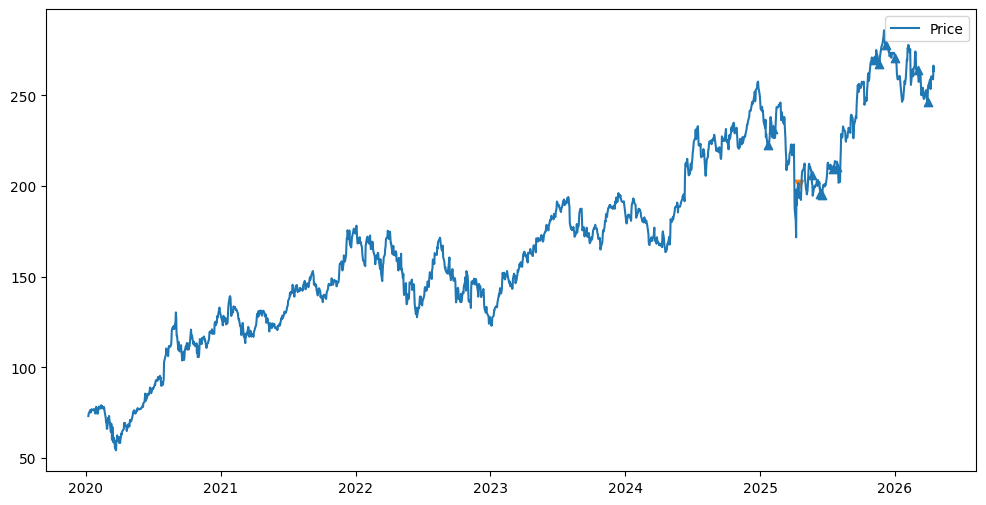

In [27]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')

plt.scatter(buy.index, buy['Close'], marker='^')
plt.scatter(sell.index, sell['Close'], marker='v')

plt.legend()
plt.show()

In [30]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

fig = px.line(data, x=data.index, y='Close', title='Trading Signals')
fig.add_scatter(x=buy.index, y=buy['Close'], mode='markers', 
                marker=dict(symbol='triangle-up', size=10, color='green'), 
                name='STRONG BUY')
fig.add_scatter(x=sell.index, y=sell['Close'], mode='markers', 
                marker=dict(symbol='triangle-down', size=10, color='red'), 
                name='STRONG SELL')
fig.show()


In [31]:
latest = data.iloc[-1]

print("Price:", latest['Close'])
print("RSI Signal:", latest['Signal'])
print("ML Signal:", latest['ML_Signal'])
print("Final Signal:", latest['Final_Signal'])

Price: 263.3999938964844
RSI Signal: HOLD
ML Signal: SELL
Final Signal: WEAK SELL


In [32]:
#confidance score
confidence = 0

if latest['Signal'] == latest['ML_Signal']:
    confidence = 2
elif latest['ML_Signal'] != 'HOLD':
    confidence = 1
else:
    confidence = 0

print("Confidence:", confidence)

Confidence: 1


In [33]:
# Decision Sytem 
if latest['Final_Signal'] == 'STRONG BUY':
    print("ENTER TRADE")
elif latest['Final_Signal'] == 'STRONG SELL':
    print("EXIT / SHORT")
else:
    print("WAIT")

WAIT
